# Agnieszka Kęska
### Porównanie modeli w przewidywaniu cen akcji -układy nieliniowe i uczenie maszynowe 

In [1]:
#import potrzebnych pakietów
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import root_mean_squared_error
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [3]:
#wczytanie i obróbka danych uzyskanych z(yfinance)
GOOG = pd.read_csv('GOOG_history1.csv').iloc[2:,].rename(columns = {'Price':'Date'})
cols = ["Close", "High", "Low", "Open", "Volume"]
GOOG["Date"] = pd.to_datetime(GOOG["Date"])
for c in cols:
    GOOG[c] = pd.to_numeric(GOOG[c], errors="coerce")
    GOOG["Date"] = pd.to_datetime(GOOG["Date"])
GOOG["Year"] = GOOG["Date"].dt.year
GOOG["Month"] = GOOG["Date"].dt.month
GOOG["Day"] = GOOG["Date"].dt.day
GOOG["Weekday"] = GOOG["Date"].dt.weekday
GOOG["DaysSinceStart"] = (GOOG["Date"] - GOOG["Date"].min()).dt.days

In [4]:
GOOG.head()

,Date,Close,High,Low,Open,Volume,Year,Month,Day,Weekday,DaysSinceStart
2,2021-01-04,85.768715,87.377150,84.756804,87.222805,38038000,2021,1,4,0,0
3,2021-01-05,86.397995,86.732984,85.261272,85.607923,22906000,2021,1,5,1,1
4,2021-01-06,86.118599,86.749366,84.317600,84.497752,52042000,2021,1,6,2,2
5,2021-01-07,88.697250,88.754317,86.205934,86.355311,45300000,2021,1,7,3,3
6,2021-01-08,89.687828,89.818349,88.016616,88.733491,41012000,2021,1,8,4,4


# Wykres cen zamknięcia akcji dla Google'a

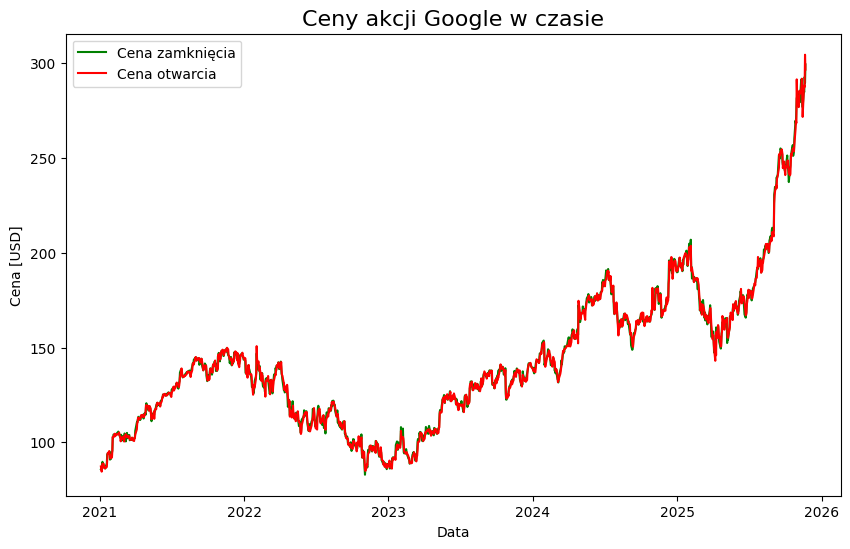

In [5]:
plt.figure(figsize=(10,6))
plt.plot(GOOG["Date"], GOOG["Close"], label="Cena zamknięcia", color="green")
plt.plot(GOOG["Date"], GOOG["Open"], label="Cena otwarcia", color="red")
plt.title("Ceny akcji Google w czasie", fontsize=16)
plt.xlabel("Data")
plt.ylabel("Cena [USD]")
plt.legend()
plt.savefig("google.pdf")
plt.show()

# Celem jest przwidzenie cen zamknięcia ackji

In [212]:
modele = []
rmse =[]
mae = []
mse = []

# Metody klasyczne

## 1. Średnia krocząca

In [213]:
# Średnie ruchome dla ceny zamknięcia
GOOG["MA_5"] = GOOG["Close"].rolling(window=5).mean()
GOOG["MA_30"] = GOOG["Close"].rolling(window=30).mean() 

GOOG = GOOG.dropna()


train_size = int(len(GOOG) * 0.8)
train_X = GOOG[["MA_5"]].iloc[:train_size]
train_y = GOOG["Close"].iloc[:train_size]
test_X = GOOG[["MA_5"]].iloc[train_size:]
test_y = GOOG["Close"].iloc[train_size:]

In [214]:
GOOG["Close_lag1"] = GOOG["Close"].shift(1)
GOOG["Close_lag2"] = GOOG["Close"].shift(2)

GOOG = GOOG.dropna()
train_size = int(len(GOOG) * 0.8)
pred_ma5 = GOOG["MA_5"].iloc[train_size:].values

mse_ma5 = mean_squared_error(test_y, pred_ma5)
mae_ma5 = mean_absolute_error(test_y, pred_ma5)
rmse_ma5 = np.sqrt(mean_squared_error(test_y, pred_ma5))
pred_ma5 = GOOG["MA_5"].iloc[train_size:].values

pred_ma30 = GOOG["MA_30"].iloc[train_size:].values
mse_ma30 = mean_squared_error(test_y, pred_ma30)
mae_ma30 = mean_absolute_error(test_y, pred_ma30)
rmse_ma30 = np.sqrt(mean_squared_error(test_y, pred_ma30))

modele.append('MA5')
rmse.append(rmse_ma5)
mse.append(mse_ma5)
mae.append(mae_ma5)

modele.append('MA30')
rmse.append(rmse_ma30)
mse.append(mse_ma30)
mae.append(mae_ma30)
                    

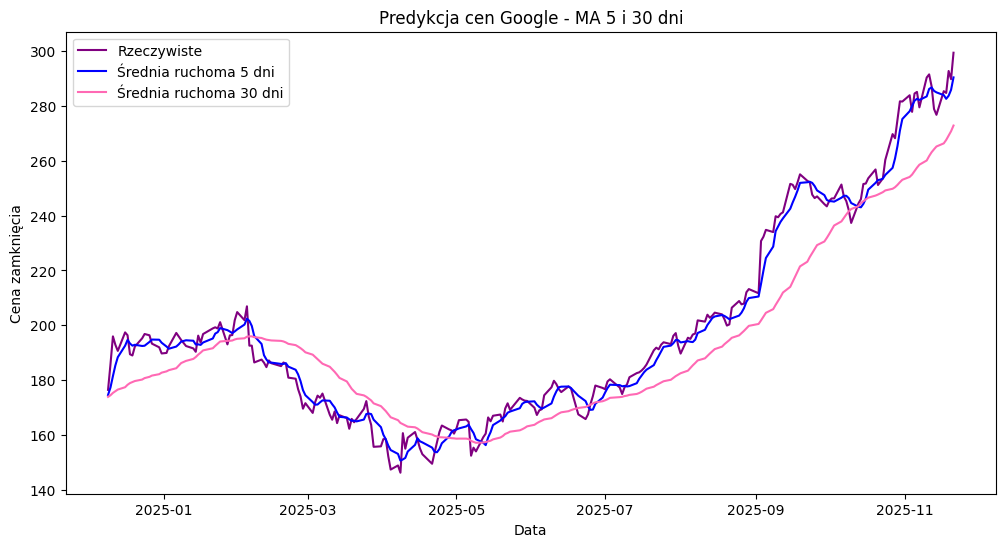

In [223]:
plt.figure(figsize=(12,6))
plt.plot(GOOG["Date"].iloc[train_size:], test_y, label="Rzeczywiste", color="purple")
plt.plot(GOOG["Date"].iloc[train_size:], pred_ma5, label="Średnia ruchoma 5 dni", color="blue")
plt.plot(GOOG["Date"].iloc[train_size:], pred_ma30, label="Średnia ruchoma 30 dni", color="hotpink")
plt.xlabel("Data")
plt.ylabel("Cena zamknięcia")
plt.title("Predykcja cen Google - MA 5 i 30 dni")
plt.legend()
plt.savefig("sredniakroczaca.pdf")
plt.show()

## 2. Wykładniczą średnia krocząca

In [217]:
GOOG["EMA_5"] = GOOG["Close"].ewm(span=5, adjust=False).mean()
GOOG["EMA_10"] = GOOG["Close"].ewm(span=10, adjust=False).mean()
GOOG["EMA_30"] = GOOG["Close"].ewm(span=30, adjust=False).mean()
GOOG = GOOG.dropna()

In [218]:
train_size = int(len(GOOG) * 0.8)

train_X = GOOG[["EMA_5"]].iloc[:train_size]
train_y = GOOG["Close"].iloc[:train_size]

test_X = GOOG[["EMA_5"]].iloc[train_size:]
test_y = GOOG["Close"].iloc[train_size:]
predictions_ema = test_X["EMA_5"].values

In [219]:
# Predykcje EMA (przesunięte o 1 dzień)
pred_ema5 = GOOG["EMA_5"].iloc[train_size:].values
pred_ema30 = GOOG["EMA_30"].iloc[train_size:].values

mse_ema5 = mean_squared_error(test_y, pred_ema5)
mae_ema5 = mean_absolute_error(test_y, pred_ema5)
rmse_ema5 = np.sqrt(mean_squared_error(test_y, pred_ema5))

mse_ema30 = mean_squared_error(test_y, pred_ema30)
mae_ema30 = mean_absolute_error(test_y, pred_ema30)
rmse_ema5 = np.sqrt(mean_squared_error(test_y, pred_ema30))

In [220]:
modele.append('EMA5')
rmse.append(rmse_ema5)
mse.append(mse_ema5)
mae.append(mae_ema5)

modele.append('EMA30')
rmse.append(rmse_ma30)
mse.append(mse_ema30)
mae.append(mae_ema30)

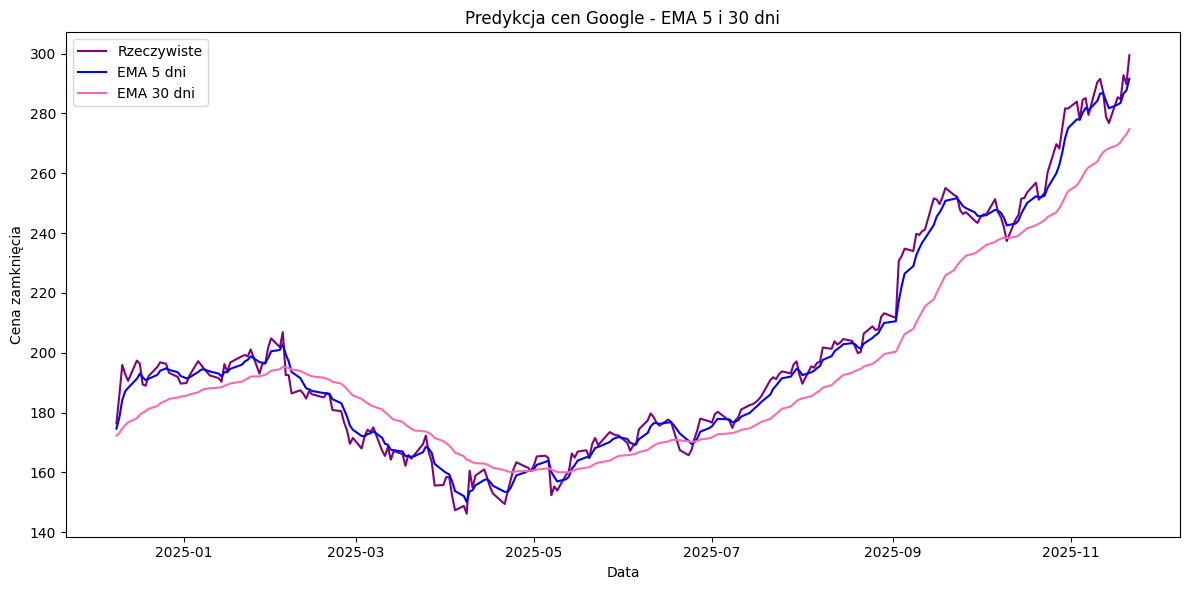

In [224]:
# Wykres
plt.figure(figsize=(12,6))
plt.plot(GOOG["Date"].iloc[train_size:], test_y, label="Rzeczywiste", color="purple")
plt.plot(GOOG["Date"].iloc[train_size:], pred_ema5, label="EMA 5 dni", color="blue")
plt.plot(GOOG["Date"].iloc[train_size:], pred_ema30, label="EMA 30 dni", color="hotpink")
plt.xlabel("Data")
plt.ylabel("Cena zamknięcia")
plt.title("Predykcja cen Google - EMA 5 i 30 dni")
plt.legend()
plt.tight_layout()
plt.savefig("ema5_30_predykcja.pdf")
plt.show()

# Modele uczenia maszynowego

## 1. Regresja logistyczna

In [230]:
y = GOOG[['Close']]
X = GOOG.drop('Close', axis = 1)
X = GOOG.drop('Date', axis = 1)

In [231]:
X = X.iloc[:,:10]

In [232]:
seq_length = 30
X_n = []
y_n = []


for i in range(len(GOOG) - seq_length):
    window = X.iloc[i:i+seq_length].values.flatten()
    X_n.append(window)
    y_n.append(GOOG['Close'].iloc[i+seq_length])


X = np.array(X_n)
y = np.array(y_n)

In [233]:
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [234]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [235]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_test_lr = lr.predict(X_test)

In [236]:
mse_lr = mean_squared_error(y_test, y_pred_test_lr)
mae_lr = mean_absolute_error(y_test, y_pred_test_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

In [238]:
modele.append('LR')
rmse.append(rmse_lr)
mse.append(mse_lr)
mae.append(mae_lr)

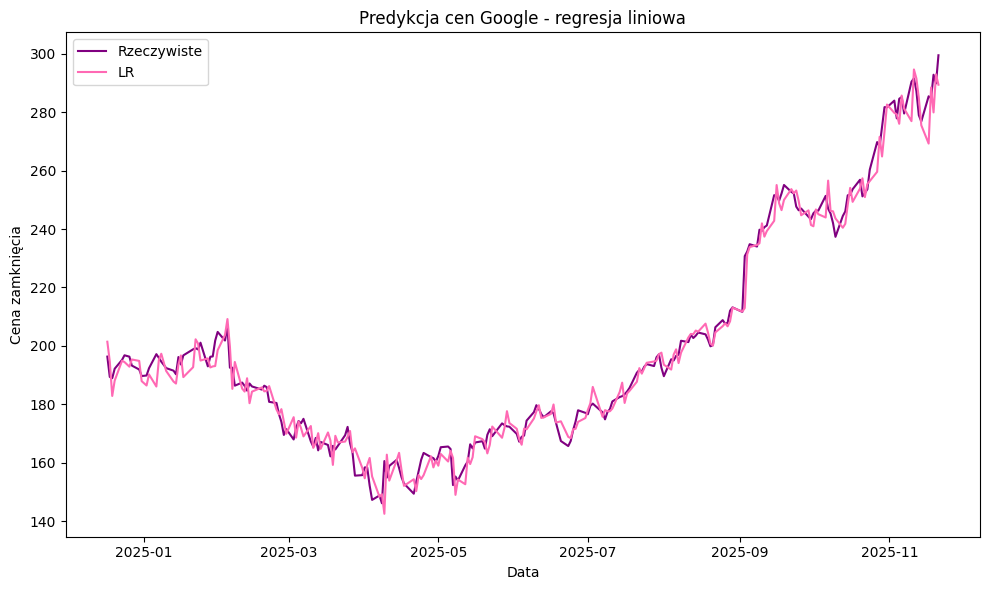

In [242]:
plt.figure(figsize=(10,6))

dates_test = GOOG['Date'].iloc[train_size+seq_length:]
plt.plot(dates_test, y_test, label='Rzeczywiste', color='purple')
plt.plot(dates_test, y_pred_test_lr, label='LR', color='hotpink')

plt.xlabel('Data')
plt.ylabel('Cena zamknięcia')
plt.title("Predykcja cen Google - regresja liniowa")
plt.legend()
plt.xticks()
plt.tight_layout()
plt.savefig("regresjaliniowa.pdf")
plt.show()

## 2. K - najbliższych sąsiadów

In [250]:
knn = KNeighborsRegressor()

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],  
    'p': [1, 2]                        
}

In [251]:
rmse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring=rmse_scorer,
    cv=5,             
    n_jobs=-1,         
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,KNeighborsRegressor()
,param_grid,"{'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,scoring,make_scorer(m...hod='predict')
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [252]:
print("Najlepsze parametry:", grid_search.best_params_)
print("Najlepszy RMSE (negatywny):", grid_search.best_score_)

Najlepsze parametry: {'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
Najlepszy RMSE (negatywny): -269.7880036482984


In [253]:
best_rmse = np.sqrt(-grid_search.best_score_)
print("Najlepszy RMSE:", best_rmse)

Najlepszy RMSE: 16.425224614850734


In [255]:
best_knn = grid_search.best_estimator_

y_test_pred_knn = best_knn.predict(X_test)
#y_train_pred = best_knn.predict(X_train)

In [257]:
mse_knn = mean_squared_error(y_test, y_test_pred_knn)
mae_knn = mean_absolute_error(y_test, y_test_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_test_pred_knn))

In [259]:
modele.append('KNN')
rmse.append(rmse_knn)
mse.append(mse_knn)
mae.append(mae_knn)

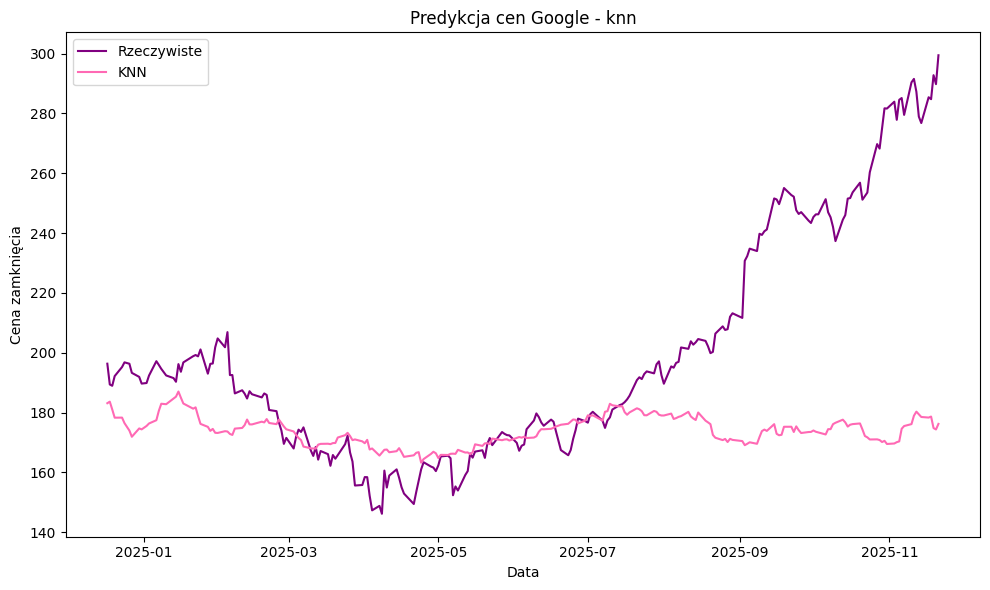

In [260]:
plt.figure(figsize=(10,6))
dates_test = GOOG['Date'].iloc[train_size+seq_length:]

plt.plot(dates_test, y_test, label='Rzeczywiste', color='purple')
plt.plot(dates_test, y_test_pred_knn, label='KNN', color='hotpink')

plt.xlabel('Data')
plt.ylabel('Cena zamknięcia')
plt.title('Predykcja cen Google - knn')
plt.legend()
plt.xticks()
plt.tight_layout()
plt.savefig("knn.pdf")
plt.show()

## 3. Las losowy

In [261]:
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [262]:
rf = RandomForestRegressor(random_state=42)

params_rf = {
    'n_estimators':[25],
    'max_depth': [3, 5, 8, 10],
    'min_samples_leaf': [5, 10, 20, 30, 100]
}

grid_rf = GridSearchCV(
    rf,
    param_grid=params_rf,
    cv=6,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    error_score='raise'
)

grid_rf.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [5, 10, ...], 'n_estimators': [25]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,6
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,n_estimators,25


In [264]:
y_pred_test_rf = grid_rf.predict(X_test)

In [265]:
mse_rf = mean_squared_error(y_test, y_pred_test_rf)
mae_rf = mean_absolute_error(y_test, y_pred_test_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))

In [266]:
modele.append('RF')
rmse.append(rmse_rf)
mse.append(mse_rf)
mae.append(mae_rf)

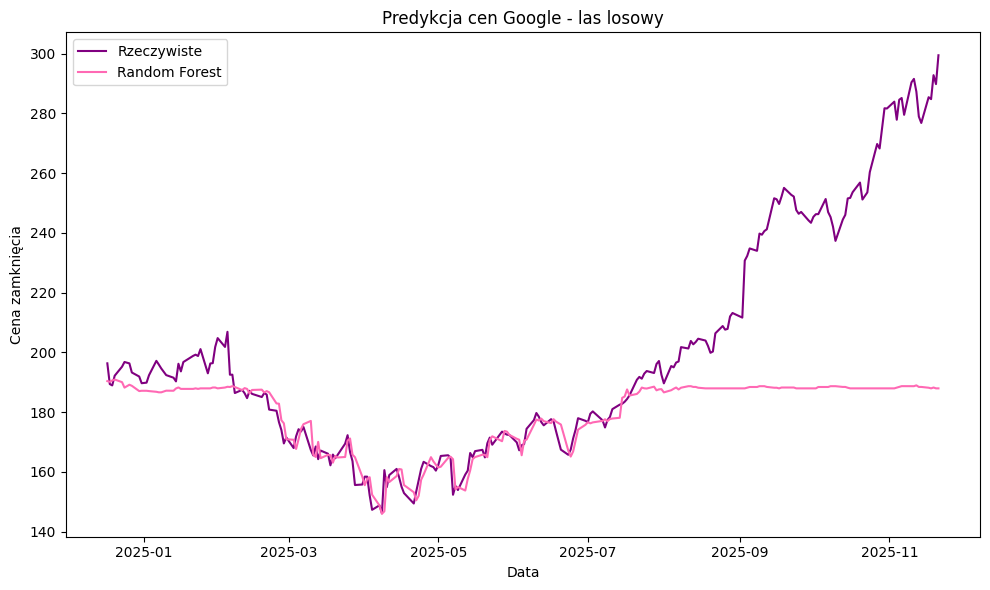

In [267]:
plt.figure(figsize=(10,6))
dates_test = GOOG['Date'].iloc[train_size+seq_length:]

plt.plot(dates_test, y_test, label='Rzeczywiste', color='purple')
plt.plot(dates_test, y_pred_test_rf, label='Random Forest', color='hotpink')

plt.xlabel('Data')
plt.ylabel('Cena zamknięcia')
plt.title('Predykcja cen Google - las losowy')
plt.legend()
plt.xticks()
plt.tight_layout()
plt.savefig("laslosowy.pdf")
plt.show()

# LSTM

In [272]:
GOOG.head()

,Date,Close,High,Low,Open,Volume,Year,Month,Day,Weekday,DaysSinceStart,MA_5,MA_30,Close_lag1,Close_lag2,EMA_5,EMA_10,EMA_30
33,2021-02-18,105.071945,105.842911,104.402467,104.733980,22432000,2021,2,18,3,45,104.887430,95.597405,105.623314,105.305183,105.071945,105.071945,105.071945
34,2021-02-19,104.274925,105.733484,104.089813,105.174679,29148000,2021,2,19,4,46,104.939537,96.202616,105.071945,105.623314,104.806272,104.927032,105.020525
35,2021-02-22,102.475426,103.792543,102.339445,102.580632,27350000,2021,2,22,0,49,104.550159,96.661889,104.274925,105.071945,104.029323,104.481286,104.856325
36,2021-02-23,102.772194,103.325546,99.355816,100.496764,33348000,2021,2,23,1,50,104.043561,97.098034,102.475426,104.274925,103.610280,104.170542,104.721865
37,2021-02-24,103.978638,104.257052,101.147872,101.331492,24966000,2021,2,24,2,51,103.714626,97.641375,102.772194,102.475426,103.733066,104.135650,104.673914


In [282]:
y = GOOG[['Close']]
X = GOOG.drop('Close', axis = 1)
X = GOOG.drop('Date', axis = 1)
X = X.iloc[:,:10]

In [283]:
y = GOOG['Close'].values
X = GOOG.drop(['Close','Date'], axis=1).iloc[:, :10].values
seq_length = 30
X_n, y_n = [], []

for i in range(len(GOOG) - seq_length):
    window = X[i:i+seq_length]
    X_n.append(window)
    y_n.append(y[i+seq_length])

X = np.array(X_n)
y = np.array(y_n)

In [284]:
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

#Skalowanie
n_features = X_train.shape[2]

scaler_X = StandardScaler()
X_train_flat = X_train.reshape(-1, n_features)
X_train_scaled_flat = scaler_X.fit_transform(X_train_flat)
X_train_scaled = X_train_scaled_flat.reshape(X_train.shape)

X_test_flat = X_test.reshape(-1, n_features)
X_test_scaled_flat = scaler_X.transform(X_test_flat)
X_test_scaled = X_test_scaled_flat.reshape(X_test.shape)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1,1))

In [285]:
X_train_tensor = torch.from_numpy(X_train_scaled).float()
y_train_tensor = torch.from_numpy(y_train_scaled).float()
X_test_tensor = torch.from_numpy(X_test_scaled).float()
y_test_tensor = torch.from_numpy(y_test_scaled).float()

In [286]:
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [287]:
model = PredictionModel(input_dim=n_features, hidden_dim=32, num_layers=2, output_dim=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [288]:
#trenowanie
num_epochs = 200
for i in range(num_epochs):
    model.train()
    y_train_pred = model(X_train_tensor)
    loss = criterion(y_train_pred, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if i % 25 == 0:
        print(f"Epoch {i}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1.0115
Epoch 25, Loss: 0.0321
Epoch 50, Loss: 0.0180
Epoch 75, Loss: 0.0140
Epoch 100, Loss: 0.0118
Epoch 125, Loss: 0.0103
Epoch 150, Loss: 0.0088
Epoch 175, Loss: 0.0075


In [289]:
model.eval()
y_test_pred = model(X_test_tensor).detach().numpy()
y_train_pred = model(X_train_tensor).detach().numpy()

In [290]:
#odwracanie skalowania
y_test_pred_orig = scaler_y.inverse_transform(y_test_pred)
y_train_pred_orig = scaler_y.inverse_transform(y_train_pred)
y_test_orig = scaler_y.inverse_transform(y_test_tensor.detach().numpy())
y_train_orig = scaler_y.inverse_transform(y_train_tensor.detach().numpy())


In [291]:
rmse_lstm = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig))
mse_lstm = mean_squared_error(y_test_orig, y_test_pred_orig)
mae_lstm = mean_absolute_error(y_test_orig, y_test_pred_orig)

In [292]:
modele.append('LSTM')
rmse.append(rmse_lstm)
mse.append(mse_lstm)
mae.append(mae_lstm)

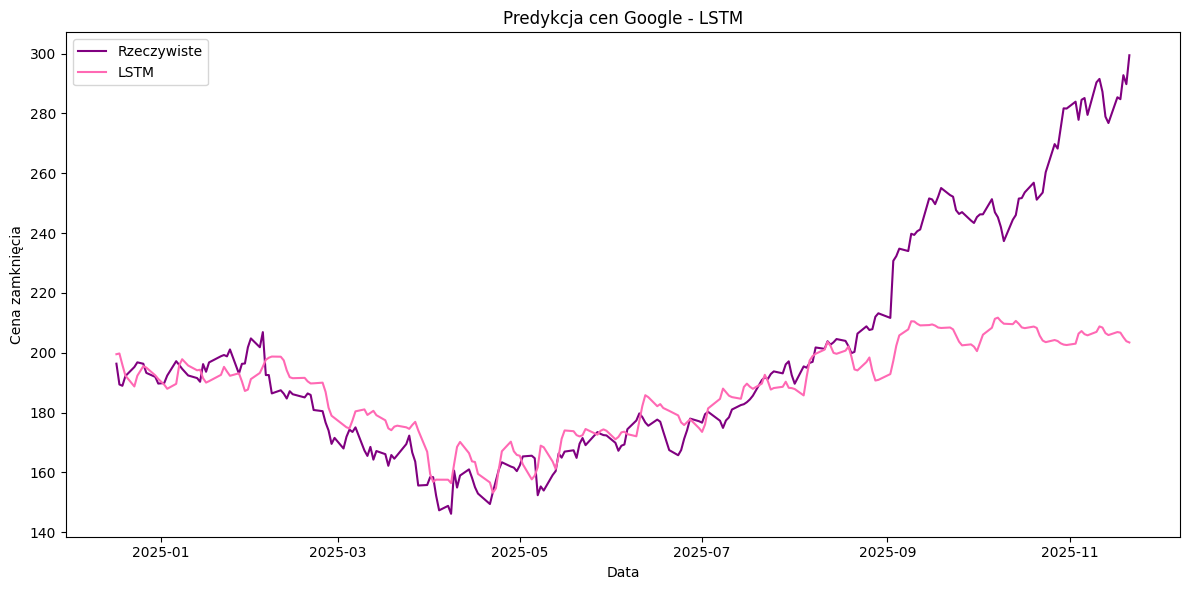

In [293]:
dates_test = GOOG['Date'].iloc[train_size + seq_length : train_size + seq_length + len(y_test_orig)]

plt.figure(figsize=(12,6))
plt.plot(dates_test, y_test_orig, label='Rzeczywiste', color='purple')
plt.plot(dates_test, y_test_pred_orig, label='LSTM', color='hotpink')
plt.xlabel('Data')
plt.ylabel('Cena zamknięcia')
plt.title('Predykcja cen Google - LSTM')
plt.legend()
plt.xticks()
plt.tight_layout()
plt.savefig("lstm.pdf")
plt.show()

In [312]:
#tabela wyników
rmse1 = np.round(rmse,2)
mse1 = np.round(mse,2)
mae1 = np.round(mae,2)
results = pd.DataFrame({
    'model': modele,
    'RMSE': rmse1,
    'MSE': mse1,
    'MAE':mae1
})

In [313]:
results

,model,RMSE,MSE,MAE
0,MA5,4.43,19.64,3.50
1,MA30,14.18,201.04,11.73
2,EMA5,12.90,13.11,2.85
3,EMA30,14.18,166.32,10.73
4,LR,4.64,21.54,3.49
5,KNN,45.21,2043.56,29.40
6,RF,37.12,1377.69,21.60
7,LSTM,28.76,826.98,17.71


In [318]:
len(pred_ma5[6:])

234

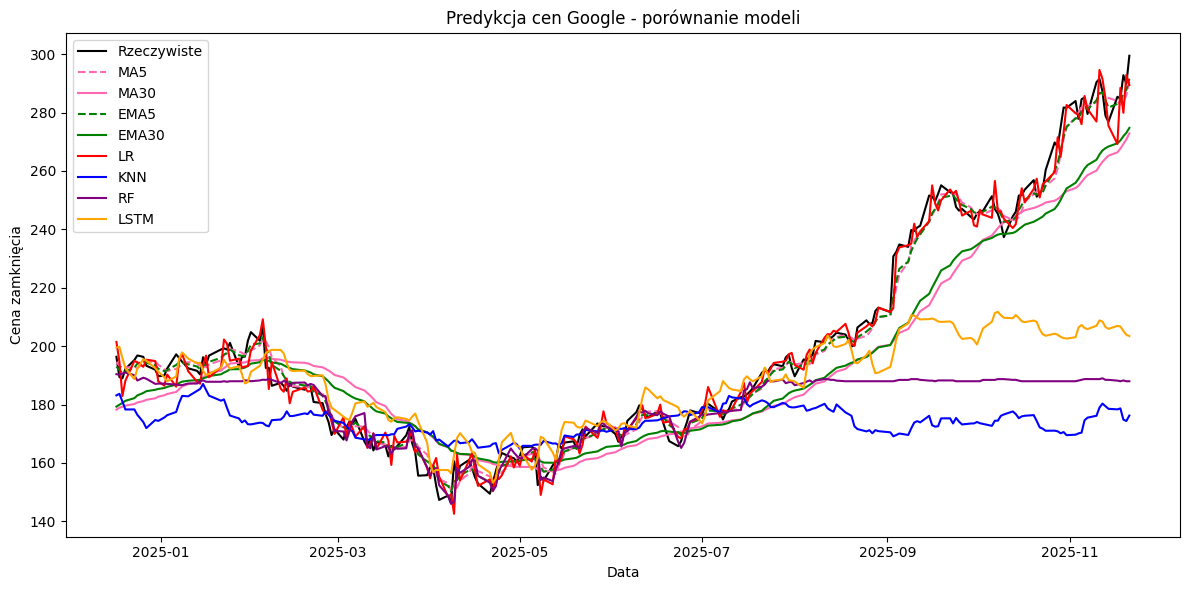

In [319]:
dates_test = GOOG['Date'].iloc[train_size + seq_length : train_size + seq_length + len(y_test_orig)]

plt.figure(figsize=(12,6))
plt.plot(dates_test, y_test_orig, label='Rzeczywiste', color='black')
plt.plot(dates_test, pred_ma5[6:], label='MA5', color='hotpink',linestyle = '--')
plt.plot(dates_test, pred_ma30[6:], label='MA30', color='hotpink')
plt.plot(dates_test, pred_ema5[6:], label='EMA5', color='green',linestyle = '--')
plt.plot(dates_test, pred_ema30[6:], label='EMA30', color='green')
plt.plot(dates_test, y_pred_test_lr, label='LR', color='red')
plt.plot(dates_test, y_test_pred_knn, label='KNN', color='blue')
plt.plot(dates_test, y_pred_test_rf, label='RF', color='purple')
plt.plot(dates_test, y_test_pred_orig, label='LSTM', color='orange')
plt.xlabel('Data')
plt.ylabel('Cena zamknięcia')
plt.title('Predykcja cen Google - porównanie modeli')
plt.legend()
plt.xticks()
plt.tight_layout()
plt.savefig("modele.pdf")
plt.show()

In [327]:
latex_table = results.to_latex(index=False, float_format="%.2f")
print(latex_table)

\begin{tabular}{lrrr}
\toprule
model & RMSE & MSE & MAE \\
\midrule
MA5 & 4.43 & 19.64 & 3.50 \\
MA30 & 14.18 & 201.04 & 11.73 \\
EMA5 & 12.90 & 13.11 & 2.85 \\
EMA30 & 14.18 & 166.32 & 10.73 \\
LR & 4.64 & 21.54 & 3.49 \\
KNN & 45.21 & 2043.56 & 29.40 \\
RF & 37.12 & 1377.69 & 21.60 \\
LSTM & 28.76 & 826.98 & 17.71 \\
\bottomrule
\end{tabular}

